In [35]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

In [36]:
df = pd.read_csv('/kaggle/input/datasets/himanibhatt300122/tewweets/Tweets.csv')

print(df.head())
print(df.columns)

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  
Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')


In [37]:
df['text'] = df['text'].fillna("")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [39]:
label_col = 'sentiment'

le = LabelEncoder()
df['label'] = le.fit_transform(df[label_col])

print(le.classes_)

['negative' 'neutral' 'positive']


In [40]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

max_len = 50
X = pad_sequences(sequences, maxlen=max_len)
y = df['label']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
import time

In [49]:
rnn_model = Sequential([
    Embedding(10000, 128, input_length=60),
    SimpleRNN(128, return_sequences=True),
    Dropout(0.3),
    SimpleRNN(64),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [50]:
%%time

start_time = time.time()

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

end_time = time.time()

print("RNN Training Time:", end_time - start_time, "seconds")

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.3851 - loss: 1.1001 - val_accuracy: 0.5472 - val_loss: 0.9359
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.6091 - loss: 0.8318 - val_accuracy: 0.6762 - val_loss: 0.7617
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.7662 - loss: 0.5916 - val_accuracy: 0.6791 - val_loss: 0.7807
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.8752 - loss: 0.3546 - val_accuracy: 0.6793 - val_loss: 0.9002
Epoch 5/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9300 - loss: 0.2189 - val_accuracy: 0.6542 - val_loss: 1.0831
Epoch 6/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9546 - loss: 0.1447 - val_accuracy: 0.6613 - val_loss: 1.1654
Epoch 7/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9639 - loss: 0.1129 - val_accuracy: 0.6584 - val_loss: 1.3287
Epoch 8/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.9703 - loss: 0.0894 - 

In [51]:
lstm_model = Sequential([
    Embedding(10000, 128, input_length=60),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [52]:
%%time

start_time = time.time()

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

end_time = time.time()

print("LSTM Training Time:", end_time - start_time, "seconds")

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.5127 - loss: 0.9588 - val_accuracy: 0.7098 - val_loss: 0.6910
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 36s 104ms/step - accuracy: 0.7700 - loss: 0.5822 - val_accuracy: 0.7158 - val_loss: 0.6759
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 36s 104ms/step - accuracy: 0.8212 - loss: 0.4663 - val_accuracy: 0.7128 - val_loss: 0.7147
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 35s 103ms/step - accuracy: 0.8583 - loss: 0.3902 - val_accuracy: 0.7069 - val_loss: 0.7724
Epoch 5/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 36s 104ms/step - accuracy: 0.8900 - loss: 0.3117 - val_accuracy: 0.7009 - val_loss: 0.8379
Epoch 6/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 36s 105ms/step - accuracy: 0.9115 - loss: 0.2484 - val_accuracy: 0.6884 - val_loss: 0.9692
Epoch 7/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 36s 105ms/step - accuracy: 0.9227 - loss: 0.2149 - val_accuracy: 0.6960 - val_loss: 1.1270
Epoch 8/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 36s 105ms/step - accuracy: 0.9435 - loss: 0

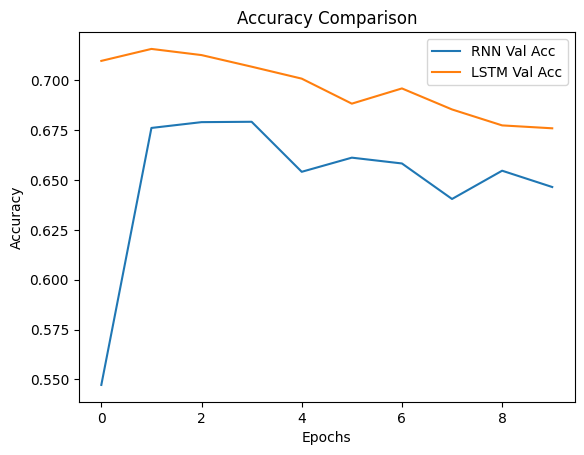

In [53]:
plt.figure()

plt.plot(history_rnn.history['val_accuracy'], label='RNN Val Acc')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Acc')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")

plt.legend()
plt.show()

In [54]:
rnn_acc = history_rnn.history['val_accuracy'][-1]
lstm_acc = history_lstm.history['val_accuracy'][-1]

print("Final RNN Accuracy:", rnn_acc)
print("Final LSTM Accuracy:", lstm_acc)

if lstm_acc > rnn_acc:
    print("LSTM Better")
else:
    print("RNN Better")

Final RNN Accuracy: 0.6465345025062561
Final LSTM Accuracy: 0.6760050654411316
LSTM Better


In [55]:
lengths = [20, 30, 40, 50, 60]

rnn_acc_list = []
lstm_acc_list = []

rnn_time_list = []
lstm_time_list = []

In [ ]:
# for max_len in lengths:

#     X_pad = pad_sequences(sequences, maxlen=max_len)

#     X_train, X_test, y_train, y_test = train_test_split(
#         X_pad, y, test_size=0.2, random_state=42
#     )

#     # -------- RNN --------
#     rnn_model = Sequential([
#         Embedding(10000, 128, input_length=max_len),
#         SimpleRNN(64),
#         Dense(3, activation='softmax')
#     ])

#     rnn_model.compile(loss='sparse_categorical_crossentropy',
#                       optimizer='adam',
#                       metrics=['accuracy'])

#     start_time = time.time()
#     rnn_model.fit(X_train, y_train, epochs=5, verbose=0)
#     end_time = time.time()

#     rnn_time_list.append(end_time - start_time)
#     rnn_acc_list.append(rnn_model.evaluate(X_test, y_test, verbose=0)[1])

#     # -------- LSTM --------
#     lstm_model = Sequential([
#         Embedding(10000, 128, input_length=max_len),
#         LSTM(64),
#         Dense(3, activation='softmax')
#     ])

#     lstm_model.compile(loss='sparse_categorical_crossentropy',
#                        optimizer='adam',
#                        metrics=['accuracy'])

#     start_time = time.time()
#     lstm_model.fit(X_train, y_train, epochs=5, verbose=0)
#     end_time = time.time()

#     lstm_time_list.append(end_time - start_time)
#     lstm_acc_list.append(lstm_model.evaluate(X_test, y_test, verbose=0)[1])

In [ ]:
# plt.figure()

# plt.plot(lengths, rnn_acc_list, marker='o', label='RNN')
# plt.plot(lengths, lstm_acc_list, marker='o', label='LSTM')

# plt.xlabel("Input Length")
# plt.ylabel("Accuracy")
# plt.title("Accuracy vs Input Length")

# plt.legend()
# plt.show()